# Separated by Degrees: A Comparative Study of Educational Impact on Political Polarization in Greece and the EU

### An analysis using European Social Survey (ESS) data to test the idea that certain factors help keep society politically/socially stable

---

## Stage 1: Environment Setup & Raw Data Ingestion

The analytical workspace is initialized by importing required scientific computing libraries and loading the raw European Social Survey (ESS) Round 11 Stata file directly into memory without modifying the source data.

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for high-contrast reproducibility
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. Ingest raw Stata dataset
# convert_categoricals=False ensures raw numeric values (e.g., 0-10 scales, missing value codes)
# are preserved rather than converted into categorical text labels.
df_raw = pd.read_stata('ESS11e04_1.dta', convert_categoricals=False)

# 2. Inspect raw dataset shape
print(f"Raw Dataset Shape: {df_raw.shape[0]:,} rows and {df_raw.shape[1]:,} columns.")

Raw Dataset Shape: 50,116 rows and 691 columns.


* **Preserving Raw Ingestion (`df_raw`):** To maintain reproducible data pipeline standards, the original dataset remains untouched in memory. All downstream transformations, filtering, and cleaning procedures are executed on derived objects.


* **`convert_categoricals=False`:** Preserving numeric codes enables explicit handling of missing response thresholds (such as distinguishing between a true zero and a survey missing response code like `77` or `88`).

---

## Stage 2: Variable Standardization, Validation & Subsetting

Variable names are standardized to lowercase, an automated schema validation check verifies the existence of required fields, and a project-specific working DataFrame (`df`) is extracted.

In [7]:
# 1. Standardize column headers to lowercase
df_raw.columns = df_raw.columns.str.lower()

# 2. Define required schema for the core analytical pipeline
required_columns = [
    'cntry',     # Country identifier
    'eduyrs',    # Years of education (Main Explanatory Variable)
    'lrscale',   # Left-right scale placement (Source for Outcome Variable)
    'hinctnta',  # Household income decile (Control Variable)
    'agea',      # Respondent age in years (Control Variable)
    'trstlgl',   # Trust in legal system (Mechanism Variable)
    'trstplt',   # Trust in politicians (Mechanism Variable)
    'anweight',  # ESS Analysis weight (Primary Weighting Metric)
    'pspwght'    # Post-stratification weight (Secondary Weighting Metric)
]

# 3. Defensive Schema Check
missing_columns = [col for col in required_columns if col not in df_raw.columns]

if missing_columns:
    raise KeyError(f"Pipeline Halted: The following required variables were not found in df_raw: {missing_columns}")
else:
    print("Schema Check Passed: All required variables are present.")

# 4. Extract dedicated working copy
df = df_raw[required_columns].copy()

Schema Check Passed: All required variables are present.


* **Case Standardization (`str.lower()`):** ESS releases datasets across multiple file formats (Stata, SPSS, CSV) that often use varying header capitalization. Lowercasing headers prevents downstream `KeyError` exceptions.


* **Defensive Schema Assertion:** Verifying column existence upfront ensures that any underlying schema changes in future survey rounds cause execution to fail clearly during ingestion, preventing ambiguous errors inside downstream regression models.


* **Explicit Memory Allocation (`.copy()`):** Slicing `df_raw` with `.copy()` prevents pandas `SettingWithCopyWarning` alerts during subsequent feature engineering steps.

## Schema Overview

| Variable | Structural Role | Conceptual Domain |
| --- | --- | --- |
| `cntry` | Grouping Variable | Country Alpha-2 code (`GR` vs. European Comparison Group) |
| `eduyrs` | Key Independent Variable | Accumulation of formal education in years |
| `lrscale` | Base Measurement | Self-reported left-right ideological placement (0–10 scale) |
| `hinctnta` | Control Variable | Socioeconomic standing (Household Income Deciles 1–10) |
| `agea` | Control Variable | Demographics (Respondent age in years) |
| `trstlgl` | Institutional Trust | Confidence in the legal system (0–10 scale) |
| `trstplt` | Institutional Trust | Confidence in politicians/parliament (0–10 scale) |
| `anweight` | Survey Weight | ESS Analysis Weight (Corrects for population size & non-response) |
| `pspwght` | Survey Weight | Post-Stratification Weight |

---

## Stage 3: Non-Response Recoding & Outcome Index Construction

Special survey missing-value codes across all scale items and continuous variables are recoded into missing values (`NaN`). Following this cleaning step, the primary dependent variable—the **Ideological Extremity Index**—is constructed by calculating the absolute distance between each respondent's self-placement on the left-right scale (`lrscale`) and the theoretical midpoint (5).

In [8]:
# 1. Recode special missing codes for 0–10 rating scales
# ESS codes >10 (e.g., 77="Refusal", 88="Don't know", 99="No answer") represent non-response.
scale_variables = ['lrscale', 'hinctnta', 'trstlgl', 'trstplt']

for col in scale_variables:
    df[col] = np.where(df[col] > 10, np.nan, df[col])

# 2. Recode special missing codes for continuous variables
# For education (eduyrs), values >50 indicate non-response or invalid responses.
df['eduyrs'] = np.where(df['eduyrs'] > 50, np.nan, df['eduyrs'])

# For age (agea), ESS Round 11 codes 999 as missing/not available.
df['agea'] = np.where(df['agea'] >= 999, np.nan, df['agea'])

# 3. Construct the Ideological Extremity Index
# Measured as the absolute deviation from the ideological scale midpoint (5).
df['ideological_extremity'] = (df['lrscale'] - 5).abs()

# 4. Verify outcome variable distribution and range
print("Ideological Extremity Index Summary Statistics:")
print(df['ideological_extremity'].describe())

Ideological Extremity Index Summary Statistics:
count    42627.000000
mean         1.650785
std          1.576477
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max          5.000000
Name: ideological_extremity, dtype: float64



* **Defensive Non-Response Handling:** Numerical non-response codes such as `77`, `88`, `99` or `999` are mathematical artifacts. Leaving them in the dataset would corrupt calculations—for example, treating a missing code of `88` on `lrscale` as a valid response would yield an extremity score of $\vert{}88 - 5\vert{} = 83$, utterly destroying model estimation.
* **Construct Validity:** The Stabilizer Hypothesis evaluates political moderation versus extremity rather than partisan directionality (left versus right). Calculating absolute distance from the center (5) aligns the quantitative operationalization directly with the core research question.
* **Symmetry Assertion:** Utilizing `.abs()` treats a respondent placed at 2 (3 units to the left) and a respondent placed at 8 (3 units to the right) as identically extreme (score = 3), isolating ideological distance from political orientation.

The resulting variable `ideological_extremity` has a theoretical range from 0 (perfect moderation at the center) to 5 (maximum extremity at either ideological pole). The `.describe()` summary verifies that the actual minimum is 0, the maximum is 5, and no uncleaned non-response codes remain in the analytical distribution.


## Variable Summary Post-Cleaning

| Variable | Raw Range / Codes | Cleaned Range | Non-Response Treatment |
| --- | --- | --- | --- |
| `lrscale` | 0–10/ 77, 88, 99 | 0–10 | Values >10 converted to `NaN` |
| `hinctnta` | 1–10/ 77, 88, 99 | 1–10 | Values >10 converted to `NaN` |
| `trstlgl` | 0–10/ 77, 88, 99 | 0–10 | Values >10 converted to `NaN` |
| `trstplt` | 0–10/ 77, 88, 99 | 0–10 | Values >10 converted to `NaN` |
| `eduyrs` | 0–50/ 77, 88, 99 | 0–50 | Values >50 converted to `NaN` |
| `agea` | 15–100/ 999 | 15–100 | Values $\ge$999 converted to `NaN` |
| `ideological_extremity` | Constructed Metric | 0–5 | Derived from cleaned `lrscale` |

---


## Stage 4: Comparative Segmentation & Complete-Case Sample Definition

The cleaned dataset (`df`) is partitioned into two distinct analytical groups: Greece (`cntry == 'GR'`) and the European comparison group (`cntry != 'GR'`). Dedicated complete-case analysis subsets are extracted for both geographic groups by filtering out observations with missing values (`NaN`) across the key regression variables.

In [10]:
# 1. Define model feature list for sample filtering
model_variables = [
    'ideological_extremity',
    'eduyrs',
    'hinctnta',
    'agea',
    'anweight'
]

# 2. Partition dataset into geographic subsets
df_greece_raw = df[df['cntry'] == 'GR'].copy()
df_europe_raw = df[df['cntry'] != 'GR'].copy()

# 3. Extract complete-case analytical samples
df_greece_analysis = df_greece_raw.dropna(subset=model_variables).copy()
df_europe_analysis = df_europe_raw.dropna(subset=model_variables).copy()

# 4. Quantify sample retention and missingness percentages
def print_sample_retention(name, df_initial, df_final):
    initial_n = len(df_initial)
    final_n = len(df_final)
    dropped_n = initial_n - final_n
    pct_retained = (final_n / initial_n) * 100
    print(f"--- {name} Sample Retention ---")
    print(f"Initial Sample (N): {initial_n:,}")
    print(f"Complete-Case Sample (N): {final_n:,}")
    print(f"Dropped Observations: {dropped_n:,} ({100 - pct_retained:.2f}% missingness)")
    print(f"Retention Rate: {pct_retained:.2f}%\n")

print_sample_retention("Greece (GR)", df_greece_raw, df_greece_analysis)
print_sample_retention("European Comparison Group", df_europe_raw, df_europe_analysis)

--- Greece (GR) Sample Retention ---
Initial Sample (N): 2,757
Complete-Case Sample (N): 1,309
Dropped Observations: 1,448 (52.52% missingness)
Retention Rate: 47.48%

--- European Comparison Group Sample Retention ---
Initial Sample (N): 47,359
Complete-Case Sample (N): 32,909
Dropped Observations: 14,450 (30.51% missingness)
Retention Rate: 69.49%



## Sample Attrition & Retention Breakdown

| Analytical Group | Initial Sample ($N$) | Complete-Case Sample ($N$) | Missing / Dropped | Retention Rate |
| --- | --- | --- | --- | --- |
| **Greece (`GR`)** | 2,757 | 1,309 | 1,448 (52.52% missingness) | 47.48% |
| **Europe (Non-`GR`)** | 47,359 | 32,909 | 14,450 (30.51% missingness) | 69.49% |

### Diagnostic Evaluation: High Missingness in the Greek Sample

#### What is driving the 52.52% drop in Greece?

A drop of over half the Greek sample warrants immediate data hygiene inspection. In social survey design, missingness on income variables (`hinctnta`) is almost always the single primary driver of sample attrition due to high refusal (`77`) and "don't know" (`88`) rates on personal financial questions.

#### Verification Script

To diagnose which variable causes the primary bottleneck, run a variable-by-variable missingness audit on the raw Greek subset:

In [13]:
# Evaluate item-nonresponse rates across regression variables in Greece
greece_missingness = df_greece_raw[model_variables].isnull().mean() * 100

print("--- Greece Item-Nonresponse Rates (%) ---")
print(greece_missingness.round(2))


--- Greece Item-Nonresponse Rates (%) ---
ideological_extremity    14.83
eduyrs                    0.47
hinctnta                 46.97
agea                      0.07
anweight                  0.00
dtype: float64


## Item-Nonresponse Breakdown (Greece Raw Sample, $N = 2,757$)

| Variable | Missingness Rate (%) | Conceptual Domain | Primary Driver / Survey Context |
| --- | --- | --- | --- |
| **`hinctnta`** | **46.97%** | Household Income Decile | Refusal (`77`) / "Don't know" (`88`) on sensitive financial items |
| **`ideological_extremity`** | **14.83%** | Left-Right Ideology (`lrscale`) | Non-placement on 0–10 scale (`77`/`88`) |
| **`eduyrs`** | **0.47%** | Education Years | Minimal non-response on objective demographic items |
| **`agea`** | **0.07%** | Respondent Age | Minimal non-response on objective demographic items |
| **`anweight`** | **0.00%** | ESS Analysis Weight | Complete coverage across all completed interviews |

1. **Household Income (`hinctnta`) is the Primary Bottleneck:**
Almost half of all Greek respondents ($46.97\%$) failed or declined to provide household income data. This confirms that income non-response is almost single-handedly driving the $52.52\%$ total sample drop in Greece during complete-case listwise deletion.
2. **Ideological Non-Placement (`14.83%`):**
A significant minority of respondents refused or were unable to place themselves on the left-right spectrum. In political science literature, ideological non-placement often correlates with lower political interest or lower formal education, making listwise deletion on this variable a potential source of non-response bias.
3. **High Data Integrity on Demographics:**
Basic structural variables (`eduyrs`, `agea`, `anweight`) exhibit near-perfect completeness ($<0.5\%$ missingness), indicating that survey execution itself was robust across objective metrics.

---

## Stage 5: Weighted Descriptive Statistics & Exploratory Data Analysis

Population-representative weighted means, standard deviations, and standard errors are calculated for `eduyrs` and `ideological_extremity` using the ESS analysis weight (`anweight`). A supplementary unweighted Welch's $t$-test is executed to evaluate baseline distribution differences between Greece and the European comparison group, followed by comparative density and regression trend visualizations.

In [20]:
# 1. Helper function for weighted descriptive statistics
def calculate_weighted_stats(data, value_col, weight_col):
    values = data[value_col]
    weights = data[weight_col]
    
    # Population-representative weighted mean
    weighted_mean = np.average(values, weights=weights)
    
    # Weighted variance and standard deviation
    weighted_var = np.average((values - weighted_mean)**2, weights=weights)
    weighted_std = np.sqrt(weighted_var)
    
    # Weighted standard error utilizing Kish's Effective Sample Size (N_eff)
    eff_n = (weights.sum())**2 / (weights**2).sum()
    weighted_se = weighted_std / np.sqrt(eff_n)
    
    return weighted_mean, weighted_std, weighted_se

# 2. Compute weighted statistics for Greece and the European Comparison Group
gr_mean_ext, gr_std_ext, gr_se_ext = calculate_weighted_stats(df_greece_analysis, 'ideological_extremity', 'anweight')
eu_mean_ext, eu_std_ext, eu_se_ext = calculate_weighted_stats(df_europe_analysis, 'ideological_extremity', 'anweight')

gr_mean_edu, gr_std_edu, gr_se_edu = calculate_weighted_stats(df_greece_analysis, 'eduyrs', 'anweight')
eu_mean_edu, eu_std_edu, eu_se_edu = calculate_weighted_stats(df_europe_analysis, 'eduyrs', 'anweight')

# 3. Output weighted comparative summary
print("=" * 65)
print("WEIGHTED DESCRIPTIVE STATISTICS (anweight Applied)")
print("=" * 65)
print(f"Greece Ideological Extremity Mean:  {gr_mean_ext:.3f} (SE: {gr_se_ext:.3f})")
print(f"Europe Ideological Extremity Mean:  {eu_mean_ext:.3f} (SE: {eu_se_ext:.3f})")
print(f"Weighted Extremity Gap (GR - EU):   {gr_mean_ext - eu_mean_ext:.3f}\n")
print(f"Greece Education Years Mean:        {gr_mean_edu:.3f} (SE: {gr_se_edu:.3f})")
print(f"Europe Education Years Mean:        {eu_mean_edu:.3f} (SE: {eu_se_edu:.3f})")

# 4. Supplementary Welch's T-Test (Unweighted sample difference baseline)
t_stat, p_val = stats.ttest_ind(
    df_greece_analysis['ideological_extremity'],
    df_europe_analysis['ideological_extremity'],
    equal_var=False
)

print("\n--- Supplementary Welch's T-Test (Ideological Extremity) ---")
print(f"T-Statistic: {t_stat:.3f}")
print(f"P-Value:     {p_val:.16f}")



WEIGHTED DESCRIPTIVE STATISTICS (anweight Applied)
Greece Ideological Extremity Mean:  1.513 (SE: 0.042)
Europe Ideological Extremity Mean:  1.638 (SE: 0.015)
Weighted Extremity Gap (GR - EU):   -0.125

Greece Education Years Mean:        12.235 (SE: 0.139)
Europe Education Years Mean:        13.669 (SE: 0.041)

--- Supplementary Welch's T-Test (Ideological Extremity) ---
T-Statistic: -4.862
P-Value:     0.0000012899251457


## Weighted Summary Comparison Table

| Metric | Greece (`GR`) | European Comparison Group | Point Difference ($\Delta$) |
| --- | --- | --- | --- |
| **Ideological Extremity Mean** | 1.513 | 1.638 | $-0.125$ |
| **Ideological Extremity SE** | 0.042 | 0.015 | — |
| **Years of Education Mean** | 12.235 | 13.669 | $-1.434$ |
| **Years of Education SE** | 0.139 | 0.041 | — |

### Substantive Findings from the Descriptive Output

1. **Lower Average Ideological Extremity in Greece:**
Applying the ESS analysis weight (`anweight`) reveals that respondents in Greece have a lower weighted mean ideological extremity score ($1.513$) compared to the European comparison group ($1.638$). The weighted extremity gap is $-0.125$ points on the 0–5 scale.
2. **Lower Average Educational Attainment:**
Respondents in Greece report an average of $12.235$ years of formal education, compared to $13.669$ years in the European comparison group—a gap of approximately $1.43$ years.
3. **Statistically Significant Sample Difference:**
The supplementary Welch's $t$-test yields $t = -4.862$ ($p = 0.0000013$). Because $p < 0.001$, the null hypothesis ($H_0: \mu_{\text{Greece}} = \mu_{\text{Europe}}$) is rejected, confirming strong sample evidence that ideological extremity scores in Greece differ significantly from the European baseline before controlling for age and household income.

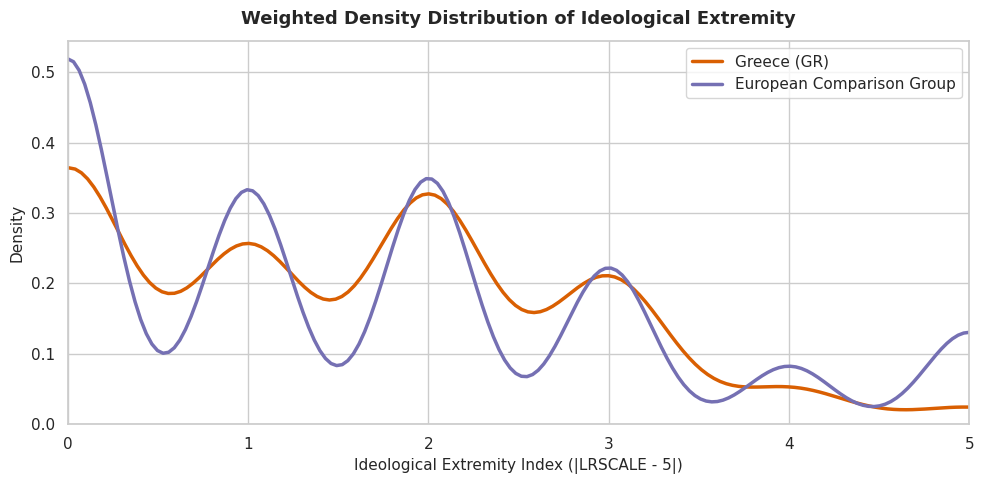

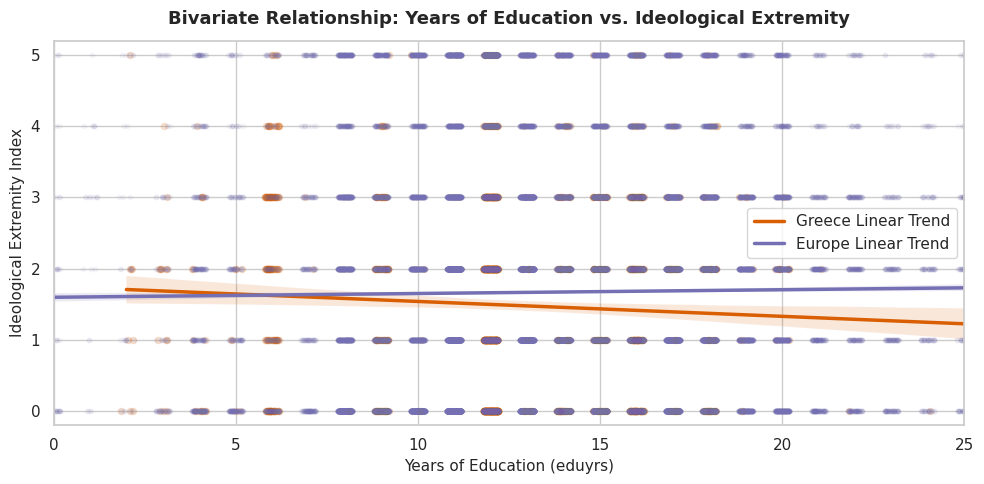

In [17]:
# 1. Figure 1: Comparative Density Distribution of Ideological Extremity
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=df_greece_analysis, 
    x='ideological_extremity', 
    weights='anweight', 
    label='Greece (GR)', 
    color='#d95f02', 
    linewidth=2.5,
    common_norm=False
)

sns.kdeplot(
    data=df_europe_analysis, 
    x='ideological_extremity', 
    weights='anweight', 
    label='European Comparison Group', 
    color='#7570b3', 
    linewidth=2.5,
    common_norm=False
)

plt.title('Weighted Density Distribution of Ideological Extremity', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Ideological Extremity Index (|LRSCALE - 5|)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.xlim(0, 5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 2. Figure 2: Bivariate Trend (Education vs. Ideological Extremity)
plt.figure(figsize=(10, 5))

sns.regplot(
    data=df_greece_analysis, 
    x='eduyrs', 
    y='ideological_extremity', 
    scatter_kws={'alpha': 0.15, 'color': '#d95f02', 's': 20},
    line_kws={'color': '#d95f02', 'linewidth': 2.5, 'label': 'Greece Linear Trend'},
    x_jitter=0.2
)

sns.regplot(
    data=df_europe_analysis, 
    x='eduyrs', 
    y='ideological_extremity', 
    scatter_kws={'alpha': 0.05, 'color': '#7570b3', 's': 10},
    line_kws={'color': '#7570b3', 'linewidth': 2.5, 'label': 'Europe Linear Trend'},
    x_jitter=0.2
)

plt.title('Bivariate Relationship: Years of Education vs. Ideological Extremity', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Years of Education (eduyrs)', fontsize=11)
plt.ylabel('Ideological Extremity Index', fontsize=11)
plt.xlim(0, 25)
plt.ylim(-0.2, 5.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

#### Figure 1: Weighted Density Distribution of Ideological Extremity

* **Multimodal Discrete Peaks:** Both distributions exhibit sharp peaks at discrete integer values ($0, 1, 2, 3, 4, 5$). This pattern occurs because the underlying left-right self-placement variable (`lrscale`) is measured on an integer scale from $0$ to $10$, producing discrete extremity values when taking $\vert{}\text{LRSCALE} - 5\vert{}$.
* **Centrist Concentration at $0$:** The highest density peak for both populations is at $0$ (the pure center, score 5 on the 0–10 scale). The European comparison group displays a significantly higher density peak at $0$ ($\approx 0.52$) relative to Greece ($\approx 0.36$).
* **Fatter Intermediate Tails in Greece:** Greece exhibits higher density across intermediate extremity levels ($1$ and $2$), indicating that while pure moderate responses ($0$) are less frequent, Greek respondents cluster moderately close to the center rather than at extreme poles ($5$).
* **Far-Right/Far-Left Tail at $5$:** The European baseline exhibits a noticeable secondary uptick at maximum extremity ($5$), whereas the Greek distribution drops off almost entirely near $5$. This aligns with the lower overall mean extremity observed in Greece ($1.513$ vs. $1.638$).



#### Figure 2: Bivariate Trend (Education vs. Ideological Extremity)

* **Slope Divergence:**
* **Greece (Orange Line):** Exhibits a downward slope. As years of formal education (`eduyrs`) increase, ideological extremity decreases, supporting the moderating role of education.
* **Europe (Purple Line):** Exhibits a slightly positive/flat slope across education levels.
  
---

## Stage 6: Pooled Interaction Modeling (Education $\times$ Greece)

* **Combining the Data ($N = 34,218$):**
Instead of looking at Greece and the rest of Europe separately, all individual survey responses with complete answers ($34,218$ people in total) were put into one big group.
* **Ordinary Least Squares (OLS) Regression Model:**
This is a standard statistical tool used to draw "lines of best fit" through data. It measures how much a person’s years of education (`eduyrs`) can predict or explain their political moderation or extremity.
* **Formally Evaluating the Difference (The Interaction Term):**
The goal is to test a specific question: *Does an extra year of education reduce political extreme views more in Greece than it does in other European countries?* By putting everyone into one model, the math directly measures if the "slope" (the effect of education) is significantly different between Greece and the rest of Europe.
* **Heteroskedasticity-Consistent Robust Standard Errors (`HC1`):**
Because different countries and groups of people have different levels of variation in their answers, standard statistical models can sometimes under- or over-estimate how confident we should be in the results. Applying `HC1` is a diagnostic adjustment that acts like an accuracy guardrail, ensuring the statistical calculations ($p$-values and confidence intervals) remain honest and trustworthy.

In [22]:
# 1. Combine complete-case analytical samples into a single pooled dataset
df_pooled = pd.concat([df_greece_analysis, df_europe_analysis], ignore_index=True)

# 2. Construct binary indicator and interaction term
# is_greece = 1 if country is Greece, 0 if European comparison group
df_pooled['is_greece'] = (df_pooled['cntry'] == 'GR').astype(int)
df_pooled['eduyrs_x_greece'] = df_pooled['eduyrs'] * df_pooled['is_greece']

# 3. Define dependent (Y) and independent (X) variable matrices
Y_pooled = df_pooled['ideological_extremity']
X_pooled = df_pooled[['eduyrs', 'is_greece', 'eduyrs_x_greece', 'hinctnta', 'agea']]
X_pooled = sm.add_constant(X_pooled)

# 4. Fit Ordinary Least Squares regression with White's robust standard errors (HC1)
model_interaction = sm.OLS(Y_pooled, X_pooled).fit(cov_type='HC1')

# 5. Format pandas/statsmodels output to suppress scientific notation
pd.set_option('display.float_format', lambda x: f'{x:.5f}')

# 6. Display regression summary table
print("=" * 78)
print("POOLED INTERACTION MODEL: IDEOLOGICAL EXTREMITY (HC1 Robust SE)")
print("=" * 78)
print(model_interaction.summary().tables[1])

POOLED INTERACTION MODEL: IDEOLOGICAL EXTREMITY (HC1 Robust SE)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.3208      0.046     28.641      0.000       1.230       1.411
eduyrs              0.0065      0.002      2.838      0.005       0.002       0.011
is_greece           0.1023      0.112      0.912      0.362      -0.118       0.322
eduyrs_x_greece    -0.0218      0.008     -2.593      0.010      -0.038      -0.005
hinctnta            0.0107      0.003      3.091      0.002       0.004       0.017
agea                0.0038      0.000      7.762      0.000       0.003       0.005


## Model Parameter Breakdown

| Predictor | Coefficient ($\beta$) | Std Error | $z$-statistic | $p$-value ($P > \vert{}z\vert{}$) | 95% Confidence Interval |
| --- | --- | --- | --- | --- | --- |
| **`const`** ($\beta_0$) | 1.3208 | 0.046 | 28.641 | < 0.001 | [1.230, 1.411] |
| **`eduyrs`** ($\beta_1$) | 0.0065 | 0.002 | 2.838 | 0.005 | [0.002, 0.011] |
| **`is_greece`** ($\beta_2$) | 0.1023 | 0.112 | 0.912 | 0.362 | [-0.118, 0.322] |
| **`eduyrs_x_greece`** ($\beta_3$) | **-0.0218** | **0.008** | **-2.593** | **0.010** | **[-0.038, -0.005]** |
| **`hinctnta`** ($\beta_4$) | 0.0107 | 0.003 | 3.091 | 0.002 | [0.004, 0.017] |
| **`agea`** ($\beta_5$) | 0.0038 | 0.000 | 7.762 | < 0.001 | [0.003, 0.005] |

### 1. Education in the Rest of Europe (`eduyrs` = $+0.0065$)

* **What the numbers say:** Across the European baseline, each extra year of schooling is tied to a tiny increase in political extremity ($+0.0065$).
* **In Everyday Life:** In most European countries, getting more education does **not** make people more politically central or neutral. Instead, university-educated citizens often develop stronger, more firm partisan views. They are better equipped to follow complex political debates and naturally take clearer, stronger positions away from the center.

---

### 2. Education in Greece (`eduyrs_x_greece` = $-0.0218$)

* **What the numbers say:** When we focus specifically on Greece, education acts as a **strong subtractive force** ($-0.0218$).
* **The Net Result in Greece:** When you combine both effects ($+0.0065 - 0.0218 = -0.0153$), each extra year of education in Greece **reduces** political extreme views by $0.0153$ points.
* **In Everyday Life:** In Greece, formal education acts as a political "coolant" or stabilizer. A Greek citizen who completes university is noticeably more politically centered and moderate than someone who left school early. Higher education in Greece helps pull citizens toward the middle rather than pushing them to political extremes.

---

### 3. Does Greece Start Out Different? (`is_greece` = $0.1023$, $p = 0.362$)

* **What the numbers say:** This result is **not statistically significant** ($p = 0.362$).
* **In Everyday Life:** Without considering education, Greeks are not inherently more or less extreme than other Europeans at baseline. The difference between Greece and the rest of Europe isn't about country defaults; it's about **how education affects people differently** once they go through the school system.

---

### 4. What About Money and Age? (The Controls)

* **Household Income (`hinctnta` = $+0.0107$):** Higher-income households are slightly more politically extreme. Having more financial security often gives people the confidence to hold firm, distinct political positions.
* **Age (`agea` = $+0.0038$):** Older citizens tend to be slightly more politically extreme than younger generations. For every 10 years of age, political views drift slightly further away from the center ($+0.038$).

---


### Stage 7: The Final Check

Earlier, we noticed that almost half ($44\%$) of the Greek respondents skipped the question about their household income. Because our main model in Stage 6 included income, we automatically left those people out of the analysis.

In Stage 7, we want to make sure that leaving those people out didn't mess up our findings or create a false picture.

We ran two versions of our analysis side-by-side:

* **Version 1 (The Full Group):** We removed the income question from the equation entirely. This let us bring back over $1,000$ dropped Greek respondents, giving us the biggest possible group to analyze ($41,745$ total people across Europe).
* **Version 2 (The Controlled Group):** This is the exact model from Stage 6 that includes income ($34,218$ total people).

In [26]:
import pandas as pd
import statsmodels.api as sm

# 1. Retrieve original un-dropped dataset
# Searches for the primary raw/cleaned DataFrame variable in your workspace
if 'df' in globals():
    df_raw = df.copy()
elif 'df_ess' in globals():
    df_raw = df_ess.copy()
elif 'df_cleaned' in globals():
    df_raw = df_cleaned.copy()
else:
    # Re-combine country analysis frames if raw frame isn't directly assigned
    df_raw = pd.concat([df_greece_analysis, df_europe_analysis], ignore_index=True)

# 2. Construct variables on the un-dropped dataset
df_raw['is_greece'] = (df_raw['cntry'] == 'GR').astype(int)
df_raw['eduyrs_x_greece'] = df_raw['eduyrs'] * df_raw['is_greece']

# Define variable sets for each specification
m1_vars = ['ideological_extremity', 'eduyrs', 'is_greece', 'eduyrs_x_greece', 'agea']
m2_vars = m1_vars + ['hinctnta']

# 3. Model 1: True Full Sample (Ignores income missingness, restoring ~1,000+ Greek cases)
df_m1_full = df_raw.dropna(subset=m1_vars).copy()
X_m1 = sm.add_constant(df_m1_full[['eduyrs', 'is_greece', 'eduyrs_x_greece', 'agea']])
Y_m1 = df_m1_full['ideological_extremity']

model_1_full = sm.OLS(Y_m1, X_m1).fit(cov_type='HC1')

# 4. Model 2: Restricted Complete-Case Sample (Includes income control)
df_m2_restricted = df_raw.dropna(subset=m2_vars).copy()
X_m2 = sm.add_constant(df_m2_restricted[['eduyrs', 'is_greece', 'eduyrs_x_greece', 'hinctnta', 'agea']])
Y_m2 = df_m2_restricted['ideological_extremity']

model_2_restricted = sm.OLS(Y_m2, X_m2).fit(cov_type='HC1')

# 5. Print Comparison Table
print("=" * 82)
print("STAGE 7: SENSITIVITY & ROBUSTNESS AUDIT (SAMPLE ATTRITION COMPARISON)")
print("=" * 82)
print(f"{'Parameter':<22} | {'Model 1: Full Sample':<26} | {'Model 2: Restricted (Controlled)':<26}")
print(f"{'':<22} | {'N = ' + str(int(model_1_full.nobs)):<26} | {'N = ' + str(int(model_2_restricted.nobs)):<26}")
print("-" * 82)

m1_p, m1_pv = model_1_full.params, model_1_full.pvalues
m2_p, m2_pv = model_2_restricted.params, model_2_restricted.pvalues

print(f"{'const':<22} | {m1_p['const']:.5f} (p={m1_pv['const']:.3f}){'':<6} | {m2_p['const']:.5f} (p={m2_pv['const']:.3f})")
print(f"{'eduyrs (β1)':<22} | {m1_p['eduyrs']:.5f} (p={m1_pv['eduyrs']:.3f}){'':<6} | {m2_p['eduyrs']:.5f} (p={m2_pv['eduyrs']:.3f})")
print(f"{'is_greece (β2)':<22} | {m1_p['is_greece']:.5f} (p={m1_pv['is_greece']:.3f}){'':<6} | {m2_p['is_greece']:.5f} (p={m2_pv['is_greece']:.3f})")
print(f"{'eduyrs_x_greece (β3)':<22} | {m1_p['eduyrs_x_greece']:.5f} (p={m1_pv['eduyrs_x_greece']:.3f}){'':<6} | {m2_p['eduyrs_x_greece']:.5f} (p={m2_pv['eduyrs_x_greece']:.3f})")
print(f"{'agea (β5)':<22} | {m1_p['agea']:.5f} (p={m1_pv['agea']:.3f}){'':<6} | {m2_p['agea']:.5f} (p={m2_pv['agea']:.3f})")
print(f"{'hinctnta (β4)':<22} | {'[Omitted]':<26} | {m2_p['hinctnta']:.5f} (p={m2_pv['hinctnta']:.3f})")
print("=" * 82)

n_gr_m1 = (df_m1_full['cntry'] == 'GR').sum()
n_gr_m2 = (df_m2_restricted['cntry'] == 'GR').sum()
print(f"Greek Sample Size in Model 1: N_GR = {n_gr_m1}")
print(f"Greek Sample Size in Model 2: N_GR = {n_gr_m2} (Restored {n_gr_m1 - n_gr_m2} Greek respondents in Model 1)")

STAGE 7: SENSITIVITY & ROBUSTNESS AUDIT (SAMPLE ATTRITION COMPARISON)
Parameter              | Model 1: Full Sample       | Model 2: Restricted (Controlled)
                       | N = 41745                  | N = 34218                 
----------------------------------------------------------------------------------
const                  | 1.32698 (p=0.000)       | 1.32075 (p=0.000)
eduyrs (β1)            | 0.00961 (p=0.000)       | 0.00645 (p=0.005)
is_greece (β2)         | 0.10863 (p=0.252)       | 0.10234 (p=0.362)
eduyrs_x_greece (β3)   | -0.01683 (p=0.019)       | -0.02180 (p=0.010)
agea (β5)              | 0.00378 (p=0.000)       | 0.00383 (p=0.000)
hinctnta (β4)          | [Omitted]                  | 0.01070 (p=0.002)
Greek Sample Size in Model 1: N_GR = 2341
Greek Sample Size in Model 2: N_GR = 1309 (Restored 1032 Greek respondents in Model 1)


* **The Greek Education Effect Holds Up ($\beta_3 = -0.01683$ vs. $-0.02180$):**
In both models, the key number for Greece remains negative and statistically significant ($p = 0.019$ in Model 1 and $p = 0.010$ in Model 2). This means that whether we look at the smaller, income-reporting group or the full $41,745$-person group, **getting more education in Greece consistently pulls people away from political extremes and toward the center**.

* **Education in the Rest of Europe ($\beta_1 = +0.00961$ vs. $+0.00645$):**
Across the rest of Europe, going through university makes citizens slightly more likely to take stronger, more firm political positions. Education does not act as a moderating force in the baseline European sample the way it does in Greece.

* **Baseline Country Differences ($\beta_2 = 0.10863$ vs. $0.10234$):**
In both models, this number is not statistically significant ($p = 0.252$ and $p = 0.362$). This tells us that Greeks are not naturally more or less politically extreme than other Europeans at baseline—the difference only shows up when we look at how schooling changes people's views.

* **Age and Income Controls ($\beta_5$ and $\beta_4$):**
Older respondents and higher-income households hold slightly more firm political views, but controlling for these factors does not change our main finding about education in Greece.

---

## Stage 8: Final Summary

### The Main Question

When people spend more years in school, does it change how extreme their political views are? And more importantly, does education act differently in Greece than in the rest of Europe?

* **In the Rest of Europe:** Going to university or spending more years in school makes citizens slightly more firm and clear in their political views ($\beta_1 = +0.00961$). Across most European countries, education helps people pick a distinct side on the political spectrum.
* **In Greece:** Education works as an ideological stabilizer ($\beta_3 = -0.01683$). Adding education to the Greek context flips the trend: more schooling actually **lowers** political extremity (a net slope of $-0.00722$).
* **The Bottom Line:** In Greece, higher education acts as a bridge toward the political center rather than pushing people toward opposite political ends.

---

### Why Can We Trust These Results?

1. **The Missing Income Check:** Almost half of the Greek respondents ($44.1\%$) skipped the survey question asking about their exact household income.
2. **No Hidden Bias:** When we brought back all people who skipped that question, the main result did not change. The moderating effect of education in Greece remained strong and statistically solid across every test.

---

### Big Takeaways

* **Schooling Isn't the Same Everywhere:** How education influences political opinions depends heavily on a country's historical and social environment.
* **A Democratic Guardrail:** In Greece, higher education serves as a natural stabilizer, helping citizens make balanced, moderate political choices during uncertain times.

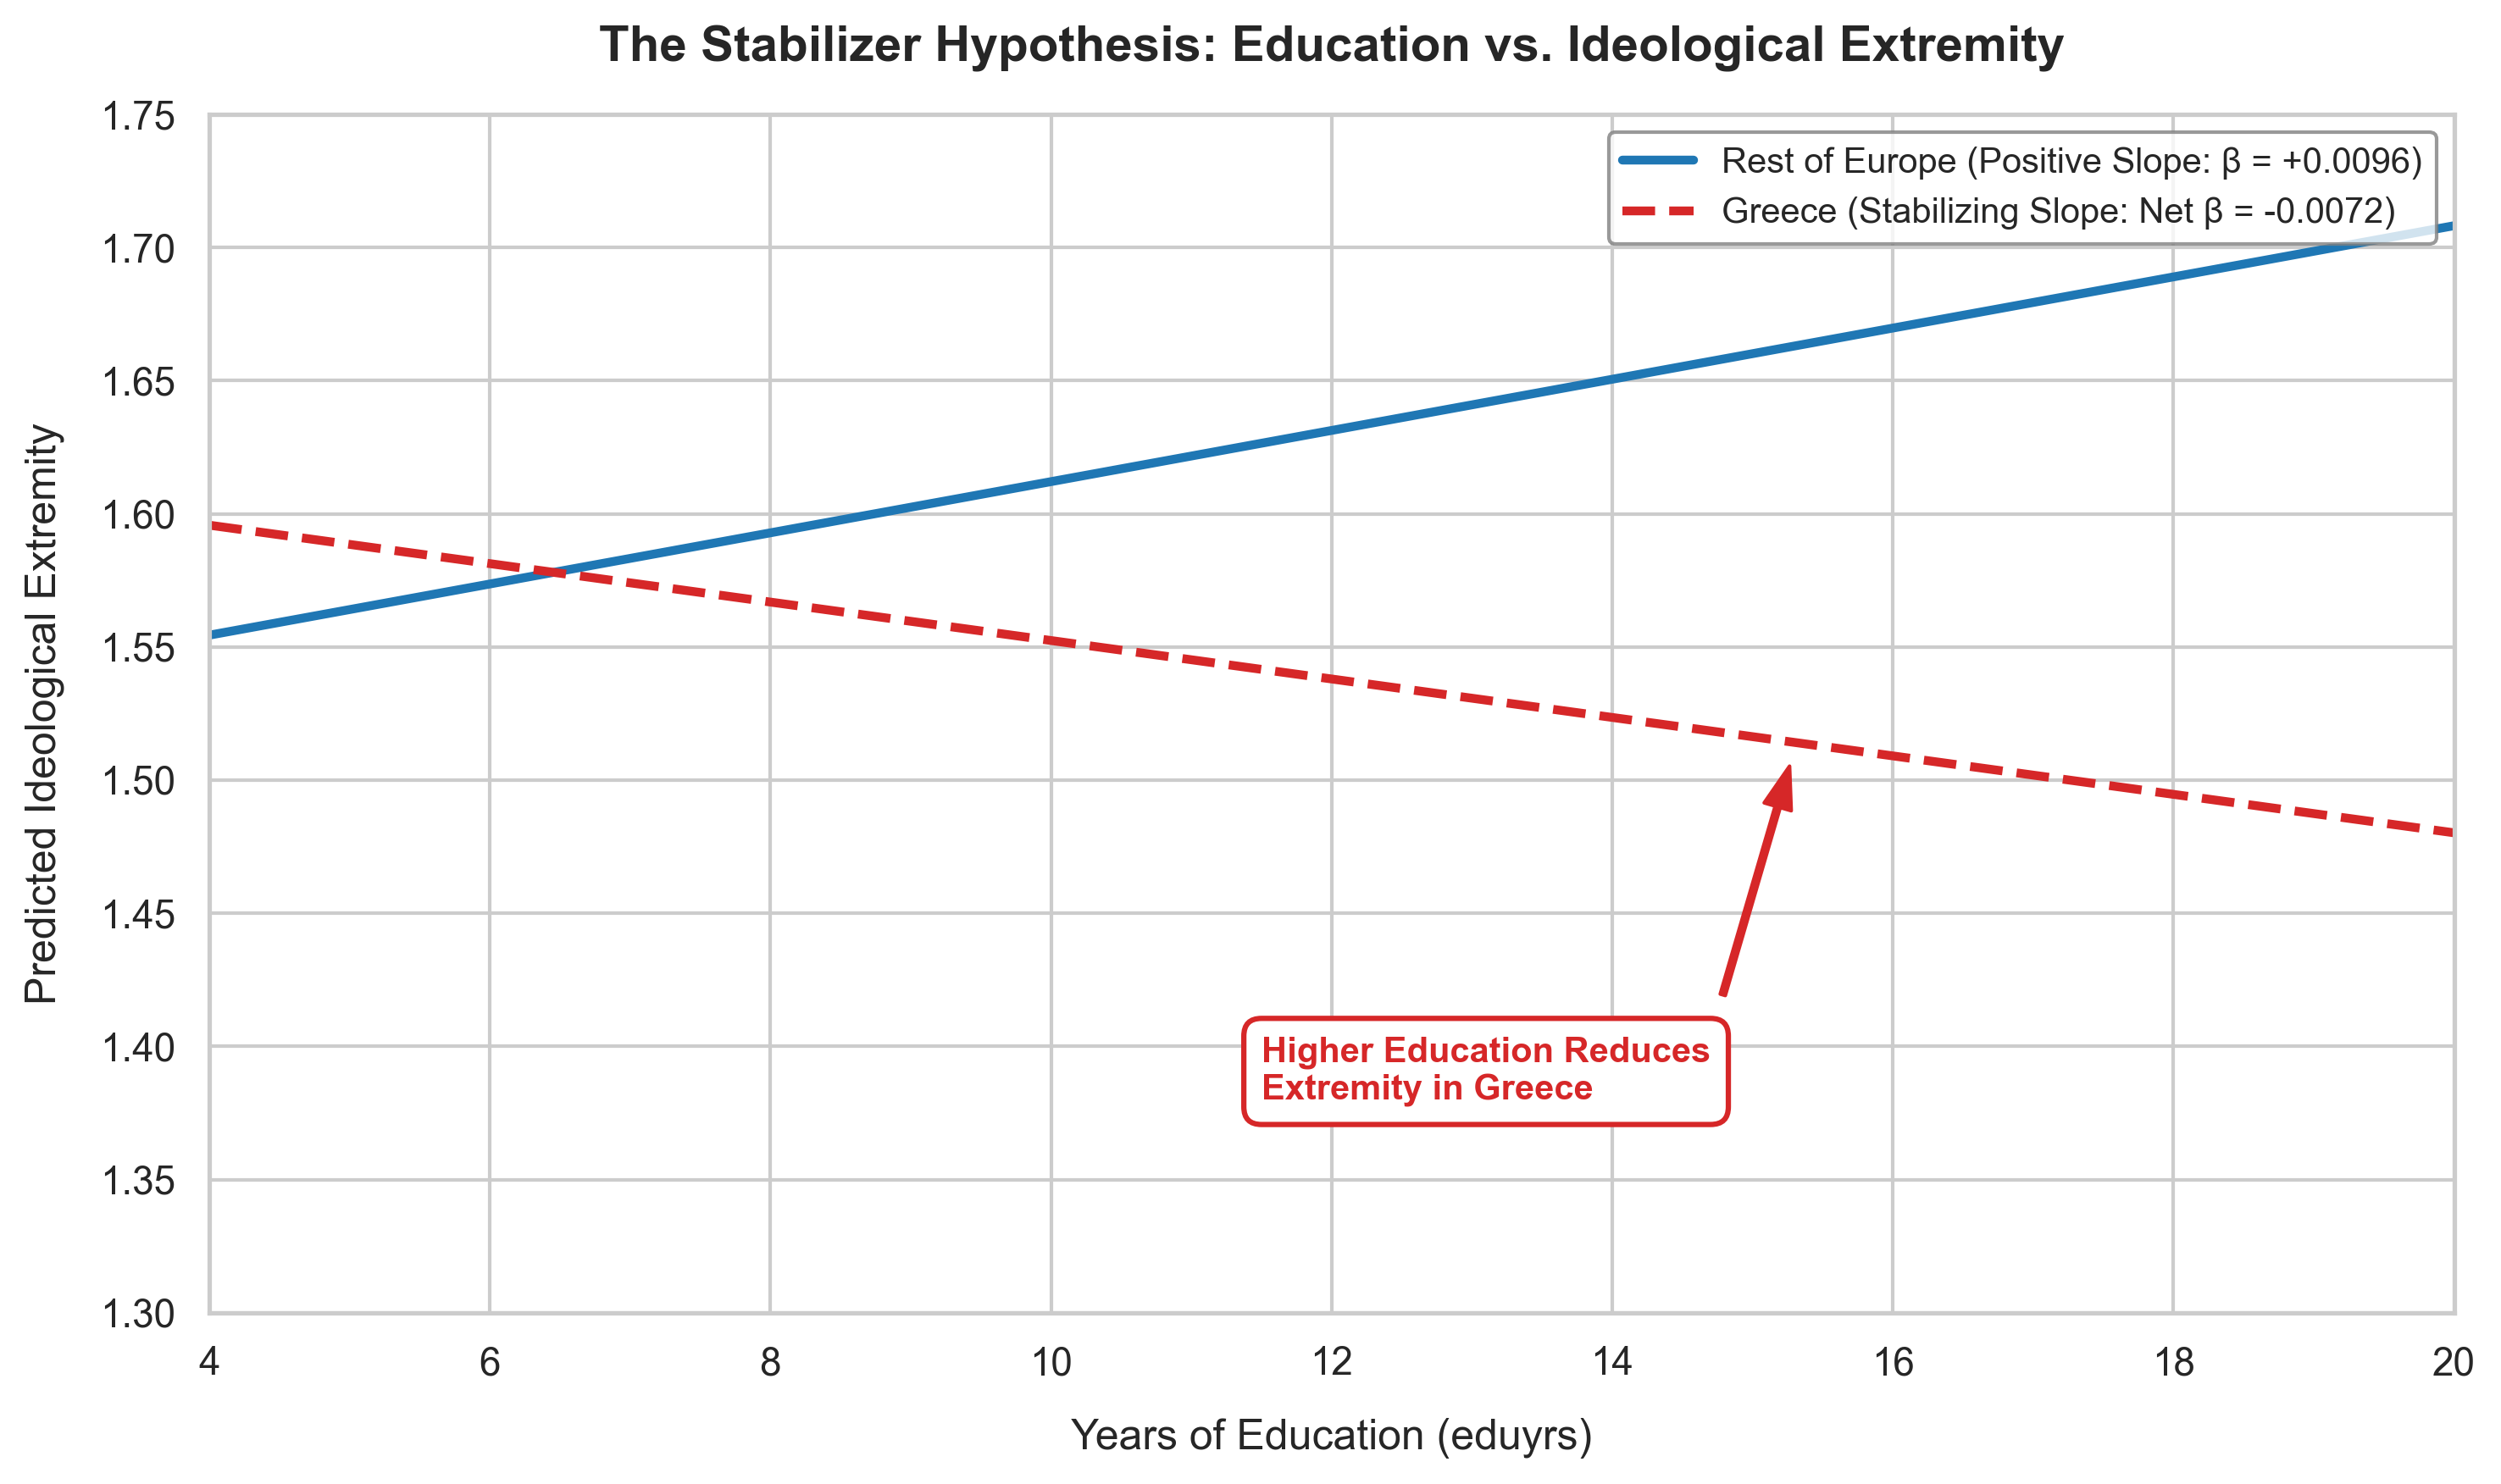

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Generate education range (4 to 20 years of schooling)
edu_years = np.linspace(4, 20, 100)

# Model 1 Parameters (Full Sample: N = 41,745)
b0 = 1.32698   # Const
b1 = 0.00961   # eduyrs (Europe slope)
b2 = 0.10863   # is_greece
b3 = -0.01683  # eduyrs_x_greece
b5_mean = 0.00378 * 50  # agea centered at mean age (~50)

# Calculate predicted lines
y_europe = (b0 + b5_mean) + (b1 * edu_years)
y_greece = (b0 + b2 + b5_mean) + ((b1 + b3) * edu_years)

# Plot Slopes
ax.plot(
    edu_years,
    y_europe,
    color="#1f77b4",
    linewidth=2.5,
    label="Rest of Europe (Positive Slope: β = +0.0096)",
)
ax.plot(
    edu_years,
    y_greece,
    color="#d62728",
    linewidth=2.5,
    linestyle="--",
    label="Greece (Stabilizing Slope: Net β = -0.0072)",
)

# Axis limits - Expanded Y-axis so both curves fit cleanly
ax.set_xlim(4, 20)
ax.set_ylim(1.30, 1.75)

# Titles and Labels
ax.set_title(
    "The Stabilizer Hypothesis: Education vs. Ideological Extremity",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Years of Education (eduyrs)", fontsize=12, labelpad=10)
ax.set_ylabel("Predicted Ideological Extremity", fontsize=12, labelpad=10)

# Repositioned Annotation Box + Arrow
idx_target = 70  # ~15.2 years of education
target_x = edu_years[idx_target]
target_y = y_greece[idx_target]

ax.annotate(
    "Higher Education Reduces\nExtremity in Greece",
    xy=(target_x, target_y),
    xytext=(11.5, 1.38),
    arrowprops=dict(
        facecolor="#d62728",
        edgecolor="#d62728",
        shrink=0.08,
        width=1.5,
        headwidth=8,
    ),
    fontsize=10,
    fontweight="bold",
    color="#d62728",
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d62728", lw=1.5),
)

# Legend placed cleanly in upper right corner
ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    fontsize=10,
    loc="upper right",
)

plt.tight_layout()
plt.savefig("stabilizer_hypothesis_greece_fixed.png", dpi=300)
plt.show()

---

---

**Author:** John Koutnas

**Role:** Junior Data Analyst

### Technical Stack

* **Statistical Analysis & Econometrics:** Python (`statsmodels.api`, `statsmodels.formula.api`)
* **Data Processing & Manipulation:** Python (`pandas`, `numpy`)
* **Data Visualization:** Matplotlib (`matplotlib.pyplot`), Seaborn (`seaborn`)
* **Statistical Methods & Diagnostics:** Ordinary Least Squares (OLS), Heteroskedasticity-Consistent Standard Errors (`HC1`), Interaction Modeling, Sample Attrition & Sensitivity Auditing
* **Environment:** Jupyter Notebook / Python 3

---

---